# VGAE Pre-training — DELCODE Whole-Brain (Schaefer-200)

Pre-trains a **Variational Graph Autoencoder** (`model/VGAE`) on whole-brain
correlation matrices, *reconstruction only* (masked adjacency BCE + β·KL), exactly
like the GAAE pre-training notebook. The trained encoder is a drop-in feature
extractor: downstream converter-vs-stable classification consumes its 64-d pooled
embedding via the `gep` / `gec` / `gelstm` adapters (set `encoder_arch: vgae`).

`conv_type` selects the encoder backbone (`gcn` = canonical VGAE, `gat` = attention);
it comes from the merged config so one notebook serves both variants. Driven by
`run_experiment.py` via `experiments.yaml`; also runnable standalone.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # reuse the runner's checkpoint slot to LOAD an existing VGAE
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = None
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json goes
RUN_NAME = None

In [2]:
# Parameters
EXPERIMENT_ID = "vgae-gcn-static"
MODE = "static"
MODEL = "VGAE"
ADAPTER = "VGAE"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
SOURCE_EXPERIMENT = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/vgae-gcn-static"
RESOLVED_CONFIG = {"seed": 100, "batch_size": 64, "learning_rate": 0.001, "weight_decay": 0.001, "beta": 1.0, "epochs": 500, "early_stopping_patience": 25, "latent_dim": 64, "hidden_dim": 128, "conv_type": "gcn", "num_heads": 2, "dropout": 0.3, "adjacency_k": 16, "num_workers": 8, "file_variant": "z_transformed"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/vgae-gcn-static/runs/ancient-grove-2-c68891b6f-2026-06-21_20-00-42"
RUN_NAME = "ancient-grove-2-c68891b6f-2026-06-21_20-00-42"


In [3]:
import os, sys, json
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
from torch_geometric.loader import DataLoader

repo_root = Path('/mnt/e/fyassine/ad-early-detection')
base_dir = repo_root / 'CLASSIFIER'
for p in (str(repo_root), str(base_dir)):
    if p not in sys.path:
        sys.path.insert(0, p)

from CLASSIFIER.common.seeding import set_seed, make_rng, make_torch_generator, seed_worker
from common.provenance import region_from_data_root
from common import tracking
from model.VGAE.models import VariationalGraphAutoencoder
from model.VGAE.train import train_vgae_with_val
from model.GAAE.dataset import GraphDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
print('Imports OK')

Imports OK


In [4]:
# reproducibility seeding — must run before datasets, samplers, or models.
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [5]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
# VGAE pre-trains on the all-cohort 'pretrain' split (like the GAAE encoder).
SPLITS_DIR = str(splits_dir('pretrain'))
TRAIN_CSV  = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV    = os.path.join(SPLITS_DIR, 'val.csv')

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION = DATA_INFO['region']
print(f"Input data: region={REGION}  atlas={DATA_INFO['atlas']}")

# Merged config (dataclass < json < hyperparams). Standalone fallback = the GCN json.
CONFIG_PATH = base_dir / 'configs' / 'vgae_gcn_delcode_whole_brain.json'
if RESOLVED_CONFIG:
    CONFIG = dict(RESOLVED_CONFIG)
elif CONFIG_PATH.exists():
    CONFIG = json.loads(CONFIG_PATH.read_text())
else:
    CONFIG = dict(seed=100, batch_size=64, learning_rate=1e-3, weight_decay=1e-3,
                  beta=1.0, epochs=500, early_stopping_patience=25, latent_dim=64,
                  hidden_dim=128, conv_type='gcn', num_heads=2, dropout=0.3,
                  adjacency_k=16, num_workers=8, file_variant='z_transformed')

CONV_TYPE   = CONFIG.get('conv_type', 'gcn')
BATCH_SIZE  = int(CONFIG.get('batch_size', 64))
LR          = float(CONFIG.get('learning_rate', 1e-3))
WEIGHT_DECAY= float(CONFIG.get('weight_decay', 1e-3))
BETA        = float(CONFIG.get('beta', 1.0))
EPOCHS      = int(CONFIG.get('epochs', 500))
PATIENCE    = int(CONFIG.get('early_stopping_patience', 25))
LATENT_DIM  = int(CONFIG.get('latent_dim', 64))
HIDDEN_DIM  = int(CONFIG.get('hidden_dim', 128))
NUM_HEADS   = int(CONFIG.get('num_heads', 2))
DROPOUT     = float(CONFIG.get('dropout', 0.3))
ADJACENCY_K = int(CONFIG.get('adjacency_k', 16))
NUM_WORKERS = int(CONFIG.get('num_workers', 8))
FILE_VARIANT= CONFIG.get('file_variant', 'z_transformed')

CKPT_ROOT = base_dir / 'notebooks' / 'checkpoints' / 'checkpoints_vgae_whole_brain'
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'conv_type={CONV_TYPE}  latent={LATENT_DIM}  hidden={HIDDEN_DIM}  beta={BETA}  adjacency_k={ADJACENCY_K}')

Input data: region=wholebrain  atlas=sch200
conv_type=gcn  latent=64  hidden=128  beta=1.0  adjacency_k=16


In [6]:
# split-hygiene audit — hard-fails if any subject crosses splits.
from CLASSIFIER.common.sanity import run_full_audit
_ = run_full_audit(split_csv_paths('pretrain'))

[SANITY] Split sizes: {'train': 241, 'val': 115, 'test': 116}
[SANITY] Pairwise-disjoint: OK


## Train vs load existing checkpoint

In [7]:
CHECKPOINT_SEARCH_DIRS = [str(CKPT_ROOT)]
_candidates = sorted(
    [d for s in CHECKPOINT_SEARCH_DIRS if Path(s).is_dir()
     for d in Path(s).iterdir() if d.is_dir() and (d / f'model_{d.name}.pth').exists()],
    key=lambda d: d.name,
)
if _candidates:
    print('  0: Train a new VGAE (default)')
    for i, d in enumerate(_candidates, 1):
        print(f'  {i}: {d.name}')
    if GAAE_CHECKPOINT_PATH is not None:
        _idx = -1   # runner supplied an explicit checkpoint to load
    elif RUN_DIR is not None:
        _idx = 0    # headless default: train new
    else:
        _s = input('Select [0=train new / 1,2,...=load, Enter=train new]: ').strip()
        _idx = int(_s) if _s.isdigit() else 0
else:
    _idx = 0
    print('No existing VGAE checkpoints — will train a new model.')

if GAAE_CHECKPOINT_PATH is not None:
    USE_EXISTING = True
    LOAD_PATH = str((base_dir / GAAE_CHECKPOINT_PATH) if not os.path.isabs(GAAE_CHECKPOINT_PATH) else GAAE_CHECKPOINT_PATH)
elif 1 <= _idx <= len(_candidates):
    USE_EXISTING = True
    LOAD_PATH = str(_candidates[_idx - 1] / f'model_{_candidates[_idx - 1].name}.pth')
else:
    USE_EXISTING = False
    LOAD_PATH = None
print('USE_EXISTING =', USE_EXISTING, '| LOAD_PATH =', LOAD_PATH)

  0: Train a new VGAE (default)
  1: vgae-gcn-static_2026-06-21_19-45-45
USE_EXISTING = False | LOAD_PATH = None


## Dataset

In [8]:
ADJACENCY_ARGS = {'k': ADJACENCY_K}
def _ds(csv):
    return GraphDatasetInMemoryFiltered(
        root=WB_DATA_ROOT, adjacency_function=knn_binary_adjacency_matrix_no_diag,
        adjacency_args=ADJACENCY_ARGS, filter_csv_path=csv, patient_info_path=csv,
        separator=',', file_variant=FILE_VARIANT,
    )
train_dataset = _ds(TRAIN_CSV)
val_dataset   = _ds(VAL_CSV)
in_features = train_dataset[0].x.size(1)
print(f'Train={len(train_dataset)}  Val={len(val_dataset)}  in_features={in_features}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, worker_init_fn=seed_worker,
                          generator=torch_gen, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, worker_init_fn=seed_worker,
                          generator=torch_gen, pin_memory=torch.cuda.is_available())

Train=371  Val=217  in_features=200


## Model

In [9]:
model = VariationalGraphAutoencoder(
    in_features=in_features, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
    conv_type=CONV_TYPE, num_heads=NUM_HEADS, dropout=DROPOUT,
).to(device)
model_config = {
    'model_type': model.__class__.__name__, 'in_features': in_features,
    'hidden_dim': HIDDEN_DIM, 'latent_dim': LATENT_DIM, 'conv_type': CONV_TYPE,
    'num_heads': NUM_HEADS, 'dropout': DROPOUT, 'beta': BETA,
}
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(f'VGAE({CONV_TYPE})  params={sum(p.numel() for p in model.parameters()):,}')

VGAE(gcn)  params=42,496


## Train (or load)

In [10]:
_wb_exp = {'id': EXPERIMENT_ID or f'vgae-{CONV_TYPE}-static', 'mode': MODE or 'static',
           'model': MODEL or 'VGAE', 'dataset': DATASET or REGION, 'seed': SEED, 'wandb': WANDB_ENABLED}
WANDB_RUN = tracking.init_run(_wb_exp, {**CONFIG, 'REGION': REGION})

if USE_EXISTING:
    obj = torch.load(LOAD_PATH, map_location=device, weights_only=False)
    if isinstance(obj, torch.nn.Module):
        model = obj.to(device)
    else:
        model.load_state_dict(obj.get('model_state_dict', obj)); model = model.to(device)
    best_model = model
    history = {'train_loss': [], 'val_loss': []}
    run_name = RUN_NAME or f'loaded_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
    run_dir = CKPT_ROOT / run_name
    print(f'Loaded VGAE from {LOAD_PATH} — training skipped.')
else:
    best_state, history = train_vgae_with_val(
        model, train_loader, val_loader, optimizer, device,
        beta=BETA, epochs=EPOCHS, early_stopping_patience=PATIENCE, wandb_run=WANDB_RUN,
    )
    model.load_state_dict(best_state); best_model = model
    ts = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    try:
        wname = WANDB_RUN.name if WANDB_RUN and getattr(WANDB_RUN, "name", None) else f'vgae-{CONV_TYPE}'
    except Exception:
        wname = f'vgae-{CONV_TYPE}'
    run_name = f'{str(wname).replace(" ", "-")}_{ts}'
    run_dir = CKPT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    # Plain-module save (matches the GAAE checkpoint convention the loaders expect).
    torch.save(best_model, run_dir / f'model_{run_name}.pth')
    (run_dir / 'run_config.json').write_text(json.dumps(
        {'run_name': run_name, 'timestamp': ts, 'model_config': model_config,
         'training_config': CONFIG, 'dataset_info': {'region': REGION, 'in_features': in_features,
         'train': len(train_dataset), 'val': len(val_dataset)}}, indent=2))
    (run_dir / 'history.json').write_text(json.dumps(history, indent=2))
    print(f'Saved VGAE checkpoint to {run_dir / ("model_" + run_name + ".pth")}')

VGAE Training:   0%|          | 0/500 [00:00<?, ?it/s]

Saved VGAE checkpoint to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/vgae-gcn-static_2026-06-21_20-08-03/model_vgae-gcn-static_2026-06-21_20-08-03.pth


In [11]:
# Runner ledger: write a run_summary.json into RUN_DIR when launched by run_experiment.py.
if RUN_DIR:
    best_val = min(history['val_loss']) if history.get('val_loss') else None
    summary = {'experiment_id': EXPERIMENT_ID, 'timestamp': datetime.now().isoformat(timespec='seconds'),
               'model_config': model_config, 'training_config': CONFIG,
               'vgae_checkpoint': str(run_dir / f'model_{run_name}.pth'),
               'metrics': {'best_val_loss': best_val}}
    (Path(RUN_DIR) / 'run_summary.json').write_text(json.dumps(summary, indent=2, default=str))
    print('Wrote', Path(RUN_DIR) / 'run_summary.json')
try:
    tracking.finish_run(WANDB_RUN)
except Exception:
    pass

Wrote /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/vgae-gcn-static/runs/ancient-grove-2-c68891b6f-2026-06-21_20-00-42/run_summary.json


## Training curve

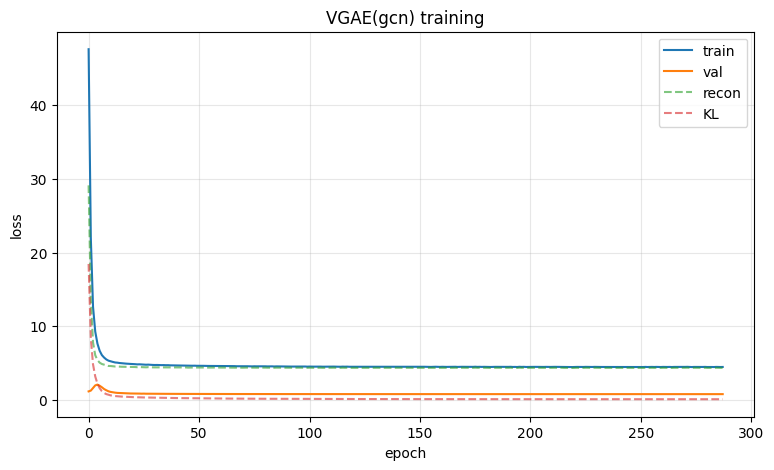

In [12]:
import matplotlib.pyplot as plt
if history.get('train_loss'):
    plt.figure(figsize=(9, 5))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    if history.get('train_recon'): plt.plot(history['train_recon'], '--', label='recon', alpha=0.6)
    if history.get('train_kl'): plt.plot(history['train_kl'], '--', label='KL', alpha=0.6)
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.title(f'VGAE({CONV_TYPE}) training'); plt.legend(); plt.grid(alpha=0.3)
    plt.show()
else:
    print('No training history (loaded checkpoint).')